# ESPCN – Super-Resolution + Segmentation on ISPRS Potsdam (patches)
**Architecture:** ESPCN with ASPP segmentation head  
**Dataset:** ISPRS Potsdam (6 classes) | flat patches folder | **Scale:** 4×


In [1]:
import subprocess, sys
pkgs = ["torch", "torchvision", "opencv-python", "scikit-image",
        "matplotlib", "tqdm", "scipy"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "--quiet"])
print(" Dependencies ready")


 Dependencies ready


In [2]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import init
import torchvision.transforms as T
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), "GB")


Device: cuda
GPU: NVIDIA GeForce RTX 5080
VRAM: 15.9 GB


In [ ]:
ROOT    = r"C:\Users\Azozi\Desktop\patches"   # Path to dataset root
IMG_DIR = os.path.join(ROOT, "images")
LBL_DIR = os.path.join(ROOT, "labels")

BEST_MODEL_PATH = "best_espcn_potsdam.pth"

# Hyper-parameters 
NUM_CLASSES                 = 6
SCALE                       = 4
EPOCHS                      = 50
BATCH                       = 4    
GRADIENT_ACCUMULATION_STEPS = 4    
LR                          = 2e-4

VALID_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

CLASS_COLORS = [
    [255, 255, 255],  # 0 Impervious (White)
    [  0,   0, 255],  # 1 Building   (Blue)
    [  0, 255, 255],  # 2 Low Veg    (Cyan)
    [  0, 255,   0],  # 3 Tree       (Green)
    [255, 255,   0],  # 4 Car        (Yellow)
    [255,   0,   0],  # 5 Clutter    (Red)
]
CLASS_NAMES = ["Impervious surfaces","Building","Low vegetation",
               "Tree","Car","Clutter/Background"]

CLASS_WEIGHTS = torch.tensor([0.5, 1.5, 1.5, 3.0, 8.0, 4.0], dtype=torch.float32)
print(" Configuration set")


 Configuration set


In [ ]:
import torchvision.models.segmentation as seg_models   

def _sorted_pairs(img_dir, lbl_dir):

    def _key(f):
        base = os.path.splitext(f)[0]
        parts = base.split("_")
        try:
            return int(parts[-1])
        except ValueError:
            return base

    imgs   = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(VALID_EXTS)], key=_key)
    labels = []
    for img_name in imgs:
        stem = os.path.splitext(img_name)[0]
        # Try Label_N with same extension, then any extension
        found = None
        for ext in VALID_EXTS:
            # Replace leading word (Image → Label) and try
            for prefix in ["Label", "label", "LABEL", "mask", "Mask"]:
                suffix = "_".join(stem.split("_")[1:])
                candidate = os.path.join(lbl_dir, f"{prefix}_{suffix}{ext}")
                if os.path.exists(candidate):
                    found = candidate
                    break
            if found: break
        if found is None:
            # Exact same filename fallback
            exact = os.path.join(lbl_dir, img_name)
            if os.path.exists(exact):
                found = exact
        if found is None:
            print(f" No label found for {img_name}, skipping")
            continue
        labels.append(found)
        imgs[imgs.index(img_name)] = os.path.join(img_dir, img_name)

    # Rebuild as full paths
    img_paths = [os.path.join(img_dir, f)
                 if not os.path.isabs(f) else f
                 for f in imgs if os.path.exists(os.path.join(img_dir, f) if not os.path.isabs(f) else f)]
    pairs = list(zip(img_paths, labels))
    return pairs


ALL_PAIRS = _sorted_pairs(IMG_DIR, LBL_DIR)
print(f"Total paired patches: {len(ALL_PAIRS)}")
if len(ALL_PAIRS) == 0:
    raise ValueError(
        f" No pairs found!\n"
        f"  IMG_DIR = {IMG_DIR}\n"
        f"  LBL_DIR = {LBL_DIR}\n"
        f"  Check that both folders exist and files share a numeric suffix."
    )

# Deterministic 70/20/10 split
np.random.seed(42)
idx   = np.random.permutation(len(ALL_PAIRS))
n     = len(ALL_PAIRS)
t_end = int(n * 0.70)
v_end = int(n * 0.90)

TRAIN_PAIRS = [ALL_PAIRS[i] for i in idx[:t_end]]
VAL_PAIRS   = [ALL_PAIRS[i] for i in idx[t_end:v_end]]
TEST_PAIRS  = [ALL_PAIRS[i] for i in idx[v_end:]]
print(f"Train: {len(TRAIN_PAIRS)} | Val: {len(VAL_PAIRS)} | Test: {len(TEST_PAIRS)}")


def parse_mask(mask_path):

    raw = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if raw is None:
        raise FileNotFoundError(f"Cannot read mask: {mask_path}")
    if len(raw.shape) == 3:
        rgb  = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        mask = np.full(rgb.shape[:2], 5, dtype=np.int64)
        for ci, color in enumerate(CLASS_COLORS):
            mask[np.all(rgb == color, axis=-1)] = ci
    else:
        mask = raw.astype(np.int64)
        mask[(mask < 0) | (mask >= NUM_CLASSES)] = 5
    return mask


class PotsdamDataset(Dataset):

    def __init__(self, pairs, scale_factor=4, augment=False):
        self.pairs   = pairs
        self.scale   = scale_factor
        self.augment = augment
        self.to_t    = T.ToTensor()

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        hr = cv2.imread(img_path)
        if hr is None:
            raise FileNotFoundError(f"Cannot read image: {img_path}")
        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

        h, w = hr.shape[:2]
        lr   = cv2.resize(hr, (w // self.scale, h // self.scale),
                          interpolation=cv2.INTER_CUBIC)
        mask = parse_mask(mask_path)

        if self.augment:
            if np.random.rand() > 0.5:
                hr, lr, mask = np.fliplr(hr).copy(), np.fliplr(lr).copy(), np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                hr, lr, mask = np.flipud(hr).copy(), np.flipud(lr).copy(), np.flipud(mask).copy()
            k = np.random.randint(4)
            if k > 0:
                hr   = np.rot90(hr,   k).copy()
                lr   = np.rot90(lr,   k).copy()
                mask = np.rot90(mask, k).copy()

        return self.to_t(lr), self.to_t(hr), torch.from_numpy(mask)


def get_train_dataset(): return PotsdamDataset(TRAIN_PAIRS, SCALE, augment=True)
def get_val_dataset():   return PotsdamDataset(VAL_PAIRS,   SCALE, augment=False)
def get_test_dataset():  return PotsdamDataset(TEST_PAIRS,  SCALE, augment=False)
print(" Dataset ready")


Total paired patches: 2400
Train: 1680 | Val: 480 | Test: 240
 Dataset ready


In [ ]:
class ASPP(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.b1   = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1,  dilation=1), nn.ReLU(True))
        self.b2   = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=2,  dilation=2), nn.ReLU(True))
        self.b4   = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=4,  dilation=4), nn.ReLU(True))
        self.fuse = nn.Conv2d(ch*3, ch, 1)
    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b4(x)], dim=1))


class ESPCNSeg(nn.Module):
    
    def __init__(self, scale_factor=4, num_classes=6, feat=64):
        super().__init__()
        self.scale = scale_factor
        self.feat_extract = nn.Sequential(
            nn.Conv2d(3, feat, 5, padding=2), nn.PReLU(),
            nn.Conv2d(feat, feat, 3, padding=1), nn.PReLU(),
            nn.Conv2d(feat, feat, 3, padding=1), nn.PReLU(),
        )
        self.aspp = ASPP(feat)
        self.subpixel = nn.Sequential(
            nn.Conv2d(feat, feat*(scale_factor**2), 3, padding=1),
            nn.PixelShuffle(scale_factor), nn.PReLU(),
        )
        self.seg_head = nn.Sequential(
            nn.Conv2d(feat, 32, 1), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(32, num_classes, 1),
        )
        self.recon = nn.Conv2d(feat, 3, 3, padding=1)
        self._icnr_init()

    def _icnr_init(self):
        sp = self.subpixel[0]; s = self.scale
        sub = init.kaiming_normal_(
            torch.empty([sp.weight.shape[0]//(s**2)] + list(sp.weight.shape[1:])),
            nonlinearity="leaky_relu")
        sp.weight.data.copy_(sub.repeat(s**2, 1, 1, 1))

    def forward(self, x):
        x       = x - 0.5
        feat    = self.aspp(self.feat_extract(x))
        hr_feat = self.subpixel(feat)
        seg_map = self.seg_head(hr_feat)
        att     = torch.softmax(seg_map, dim=1).max(dim=1, keepdim=True)[0]
        hr_feat = hr_feat * (1.0 + att)
        return self.recon(hr_feat) + 0.5, seg_map

_m = ESPCNSeg(SCALE, NUM_CLASSES)
_sr, _seg = _m(torch.randn(1, 3, 64, 64))
print(f" ESPCNSeg  SR: {tuple(_sr.shape)}  Seg: {tuple(_seg.shape)}")
print(f"   Parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _sr, _seg


 ESPCNSeg  SR: (1, 3, 256, 256)  Seg: (1, 6, 256, 256)
   Parameters: 805,965


In [6]:
l1_loss = nn.L1Loss()

def edge_loss(sr, hr):
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32,
                       device=sr.device).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32,
                       device=sr.device).view(1,1,3,3)
    sg, hg = sr.mean(1, keepdim=True), hr.mean(1, keepdim=True)
    se = torch.abs(F.conv2d(sg,kx,padding=1)) + torch.abs(F.conv2d(sg,ky,padding=1))
    he = torch.abs(F.conv2d(hg,kx,padding=1)) + torch.abs(F.conv2d(hg,ky,padding=1))
    return F.l1_loss(se, he)

def dice_loss(pred_logits, target, num_classes=NUM_CLASSES, eps=1e-6):
    ps = torch.softmax(pred_logits, dim=1)
    oh = F.one_hot(target, num_classes).permute(0,3,1,2).float()
    inter = (ps * oh).sum(dim=(2,3))
    card  = ps.sum(dim=(2,3)) + oh.sum(dim=(2,3))
    return (1.0 - (2.0*inter+eps)/(card+eps)).mean()

def focal_loss(pred_logits, target, cw, gamma=2.0):
    ce    = F.cross_entropy(pred_logits, target, weight=cw, reduction="none")
    focal = ((1 - torch.exp(-ce))**gamma) * ce
    return focal.mean()

def seg_loss(pred_logits, target, ce_fn, cw):
    return (0.4*ce_fn(pred_logits, target)
          + 0.4*dice_loss(pred_logits, target)
          + 0.2*focal_loss(pred_logits, target, cw))

print(" Loss functions defined")


 Loss functions defined


In [ ]:
def train(model_cls, model_kwargs, save_path, epochs=EPOCHS, batch=BATCH,
          lr=LR, grad_acc=GRADIENT_ACCUMULATION_STEPS):
    train_ds = get_train_dataset()
    val_ds   = get_val_dataset()
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=2,     shuffle=False,
                              num_workers=0, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

    model     = model_cls(**model_kwargs).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler    = torch.amp.GradScaler("cuda")

    ce_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE), label_smoothing=0.1)
    cw    = CLASS_WEIGHTS.to(DEVICE)

    best_psnr, history = 0.0, []

    for epoch in range(epochs):
        model.train(); epoch_loss = 0.0; optimizer.zero_grad()

        for i, (lr_b, hr_b, mask_b) in enumerate(
                tqdm(train_loader, desc=f"Epoch {epoch+1:3d}/{epochs}")):
            lr_b, hr_b, mask_b = lr_b.to(DEVICE), hr_b.to(DEVICE), mask_b.to(DEVICE)

            with torch.amp.autocast("cuda"):
                sr_b, seg_map = model(lr_b)
                # Align spatial dims 
                hs, ws = sr_b.shape[2:]; hh, wh = hr_b.shape[2:]
                t = (hh - hs) // 2; l = (wh - ws) // 2
                hr_c = hr_b[:, :, t:t+hs, l:l+ws]
                # Align seg to mask
                if seg_map.shape[2:] != mask_b.shape[1:]:
                    seg_map = F.interpolate(seg_map, size=mask_b.shape[1:],
                                            mode="bilinear", align_corners=False)
                    
                loss = 0.25 * l1_loss + 0.60 * seg_loss + 0.15 * edge_loss    
     
            scaler.scale(loss).backward()
            if (i+1) % grad_acc == 0 or (i+1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            epoch_loss += loss.item() * grad_acc

        avg_loss = epoch_loss / len(train_loader)
        history.append(avg_loss)
        scheduler.step()

        if (epoch+1) % 5 == 0 or epoch == epochs-1:
            model.eval(); psnrs = []; ious_accum = np.zeros(NUM_CLASSES)
            conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
            with torch.no_grad():
                for lr_b, hr_b, mask_b in tqdm(val_loader, desc="  Val"):
                    sr_b, seg_b = model(lr_b.to(DEVICE))
                    for j in range(sr_b.shape[0]):
                        sr_i = np.clip(sr_b[j].cpu().numpy().transpose(1,2,0), 0, 1)
                        hr_i = np.clip(hr_b[j].cpu().numpy().transpose(1,2,0), 0, 1)
                        psnrs.append(psnr_fn(hr_i, sr_i, data_range=1.0))
                    if seg_b.shape[2:] != mask_b.shape[1:]:
                        seg_b = F.interpolate(seg_b.to(DEVICE), size=mask_b.shape[1:],
                                              mode="bilinear", align_corners=False)
                    pred = seg_b.argmax(1).cpu().numpy().flatten()
                    gt   = mask_b.numpy().flatten()
                    conf += np.bincount(gt*NUM_CLASSES+pred,
                                        minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)

            tp   = np.diag(conf)
            iou  = tp / (conf.sum(0) + conf.sum(1) - tp + 1e-15)
            miou = iou.mean()
            avg_psnr = np.mean(psnrs)
            tqdm.write(f"  Loss: {avg_loss:.4f} | PSNR: {avg_psnr:.2f} dB | mIoU: {miou:.4f}")
            if avg_psnr > best_psnr:
                best_psnr = avg_psnr
                torch.save(model.state_dict(), save_path)
                tqdm.write(f"  >>> SAVED BEST ({save_path}) PSNR={best_psnr:.2f}")
        else:
            tqdm.write(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

    return model, history


Train: 1680 | Val: 480


Epoch   1/50: 100%|██████████| 420/420 [00:25<00:00, 16.20it/s]


Epoch   1 | Loss: 0.7400


Epoch   2/50: 100%|██████████| 420/420 [00:25<00:00, 16.58it/s]


Epoch   2 | Loss: 0.6848


...

Epoch  48 | Loss: 0.5082


Epoch  49/50: 100%|██████████| 420/420 [00:21<00:00, 19.14it/s]


Epoch  49 | Loss: 0.5083


  Val: 100%|██████████| 240/240 [00:05<00:00, 41.92it/s]

  Loss: 0.5083 | PSNR: 26.05 dB | mIoU: 0.2988
  >>> SAVED BEST (best_espcn_potsdam.pth) PSNR=26.05


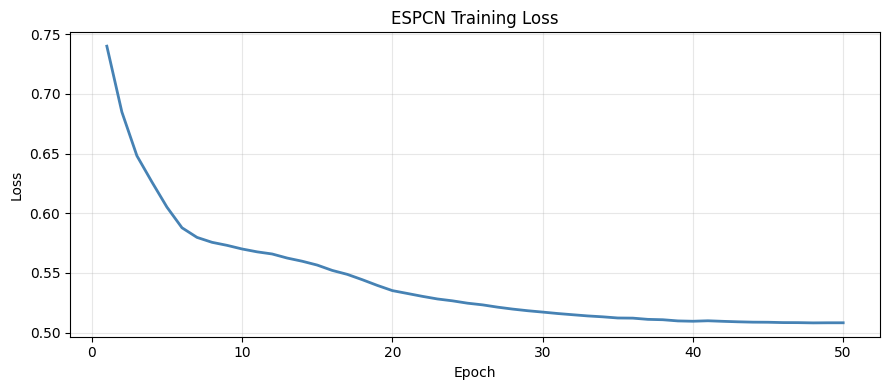

In [ ]:
model, history = train(
    model_cls    = ESPCNSeg,
    model_kwargs = dict(scale_factor=SCALE, num_classes=NUM_CLASSES),
    save_path    = BEST_MODEL_PATH,
)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(history)+1), history, linewidth=2, color="steelblue")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("ESPCN Training Loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [9]:
def classmap_to_color(cls_map):
    c = np.zeros((*cls_map.shape, 3), dtype=np.uint8)
    for ci, rgb in enumerate(CLASS_COLORS):
        c[cls_map == ci] = rgb
    return c

def make_legend():
    return [mpatches.Patch(color=[c/255 for c in rgb], label=name)
            for name, rgb in zip(CLASS_NAMES, CLASS_COLORS)]

def evaluate(model, save_path=None):
    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))
        print(f" Loaded best weights from {save_path}")
    model.eval()
    val_loader = DataLoader(get_val_dataset(), batch_size=1, shuffle=False, num_workers=0)
    psnr_list, ssim_list = [], []
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    with torch.no_grad():
        for lr_b, hr_b, mask_b in tqdm(val_loader, desc="Evaluating"):
            sr_b, seg_b = model(lr_b.to(DEVICE))
            sr_np = np.clip(sr_b.squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
            hr_np = np.clip(hr_b.squeeze().permute(1,2,0).numpy(), 0, 1)
            psnr_list.append(psnr_fn(hr_np, sr_np, data_range=1.0))
            ssim_list.append(ssim_fn(hr_np, sr_np, channel_axis=2, data_range=1.0))
            if seg_b.shape[2:] != mask_b.shape[1:]:
                seg_b = F.interpolate(seg_b.to(DEVICE), size=mask_b.shape[1:],
                                      mode="bilinear", align_corners=False)
            pred = seg_b.argmax(1).cpu().numpy().flatten()
            gt   = mask_b.numpy().flatten()
            conf += np.bincount(gt*NUM_CLASSES+pred,
                                minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)

    tp   = np.diag(conf)
    fp   = conf.sum(0) - tp
    fn   = conf.sum(1) - tp
    eps  = 1e-15
    iou  = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = 2*prec*rec / (prec+rec+eps)
    acc  = tp.sum() / conf.sum()
    miou = iou.mean()

    print("\n" + "="*55)
    print("    EVALUATION RESULTS")
    print("="*55)
    print(f"  PSNR     : {np.mean(psnr_list):.2f} dB")
    print(f"  SSIM     : {np.mean(ssim_list):.4f}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  mIoU     : {miou:.4f}  ({miou*100:.1f}%)")
    print(f"  Macro F1 : {f1.mean():.4f}")
    print("\n  PER-CLASS IoU + F1")
    print("="*55)
    for name, iu, f in zip(CLASS_NAMES, iou, f1):
        bar = "#" * int(iu*20)
        print(f"  {name:22s}: IoU={iu:.3f}  F1={f:.3f}  {bar}")
    print("="*55)
    return model

def visualize_sample(model, n=4):
    model.eval()
    ds = get_val_dataset()
    idxs = np.random.choice(len(ds), min(n, len(ds)), replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(20, 5*n))
    if n == 1: axes = [axes]
    for row, idx in enumerate(idxs):
        lr_t, hr_t, mask_t = ds[idx]
        with torch.no_grad():
            sr_b, seg_b = model(lr_t.unsqueeze(0).to(DEVICE))
        if seg_b.shape[2:] != mask_t.shape:
            seg_b = F.interpolate(seg_b, size=mask_t.shape,
                                  mode="bilinear", align_corners=False)
        lr_np  = cv2.resize(lr_t.permute(1,2,0).numpy(),
                            (hr_t.shape[2], hr_t.shape[1]), interpolation=cv2.INTER_NEAREST)
        sr_np  = np.clip(sr_b.squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
        hr_np  = hr_t.permute(1,2,0).numpy()
        seg_c  = classmap_to_color(seg_b.argmax(1).squeeze().cpu().numpy())
        gt_c   = classmap_to_color(mask_t.numpy())
        p = psnr_fn(hr_np, sr_np, data_range=1.0)
        s = ssim_fn(hr_np, sr_np, channel_axis=2, data_range=1.0)
        for ax, (img, t) in zip(axes[row], [
            (lr_np, "LR Input"),
            (sr_np, f"SR  PSNR={p:.1f}dB SSIM={s:.3f}"),
            (seg_c, "Prediction"),
            (gt_c,  "Ground Truth"),
        ]):
            ax.imshow(img); ax.set_title(t, fontsize=10); ax.axis("off")
        axes[row][2].legend(handles=make_legend(), loc="upper right",
                            bbox_to_anchor=(1,1.05), fontsize=6, framealpha=0.9)
    plt.tight_layout()
    plt.savefig("sample_output.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(">>> Saved: sample_output.png")


 Loaded best weights from best_espcn_potsdam.pth


Evaluating: 100%|██████████| 480/480 [00:08<00:00, 55.92it/s]



    EVALUATION RESULTS
  PSNR     : 26.05 dB
  SSIM     : 0.5879
  Accuracy : 0.5496  (55.0%)
  mIoU     : 0.2988  (29.9%)
  Macro F1 : 0.4361

  PER-CLASS IoU + F1
  Impervious surfaces   : IoU=0.535  F1=0.697  ##########
  Building              : IoU=0.315  F1=0.479  ######
  Low vegetation        : IoU=0.439  F1=0.610  ########
  Tree                  : IoU=0.042  F1=0.081  
  Car                   : IoU=0.210  F1=0.347  ####
  Clutter/Background    : IoU=0.252  F1=0.403  #####


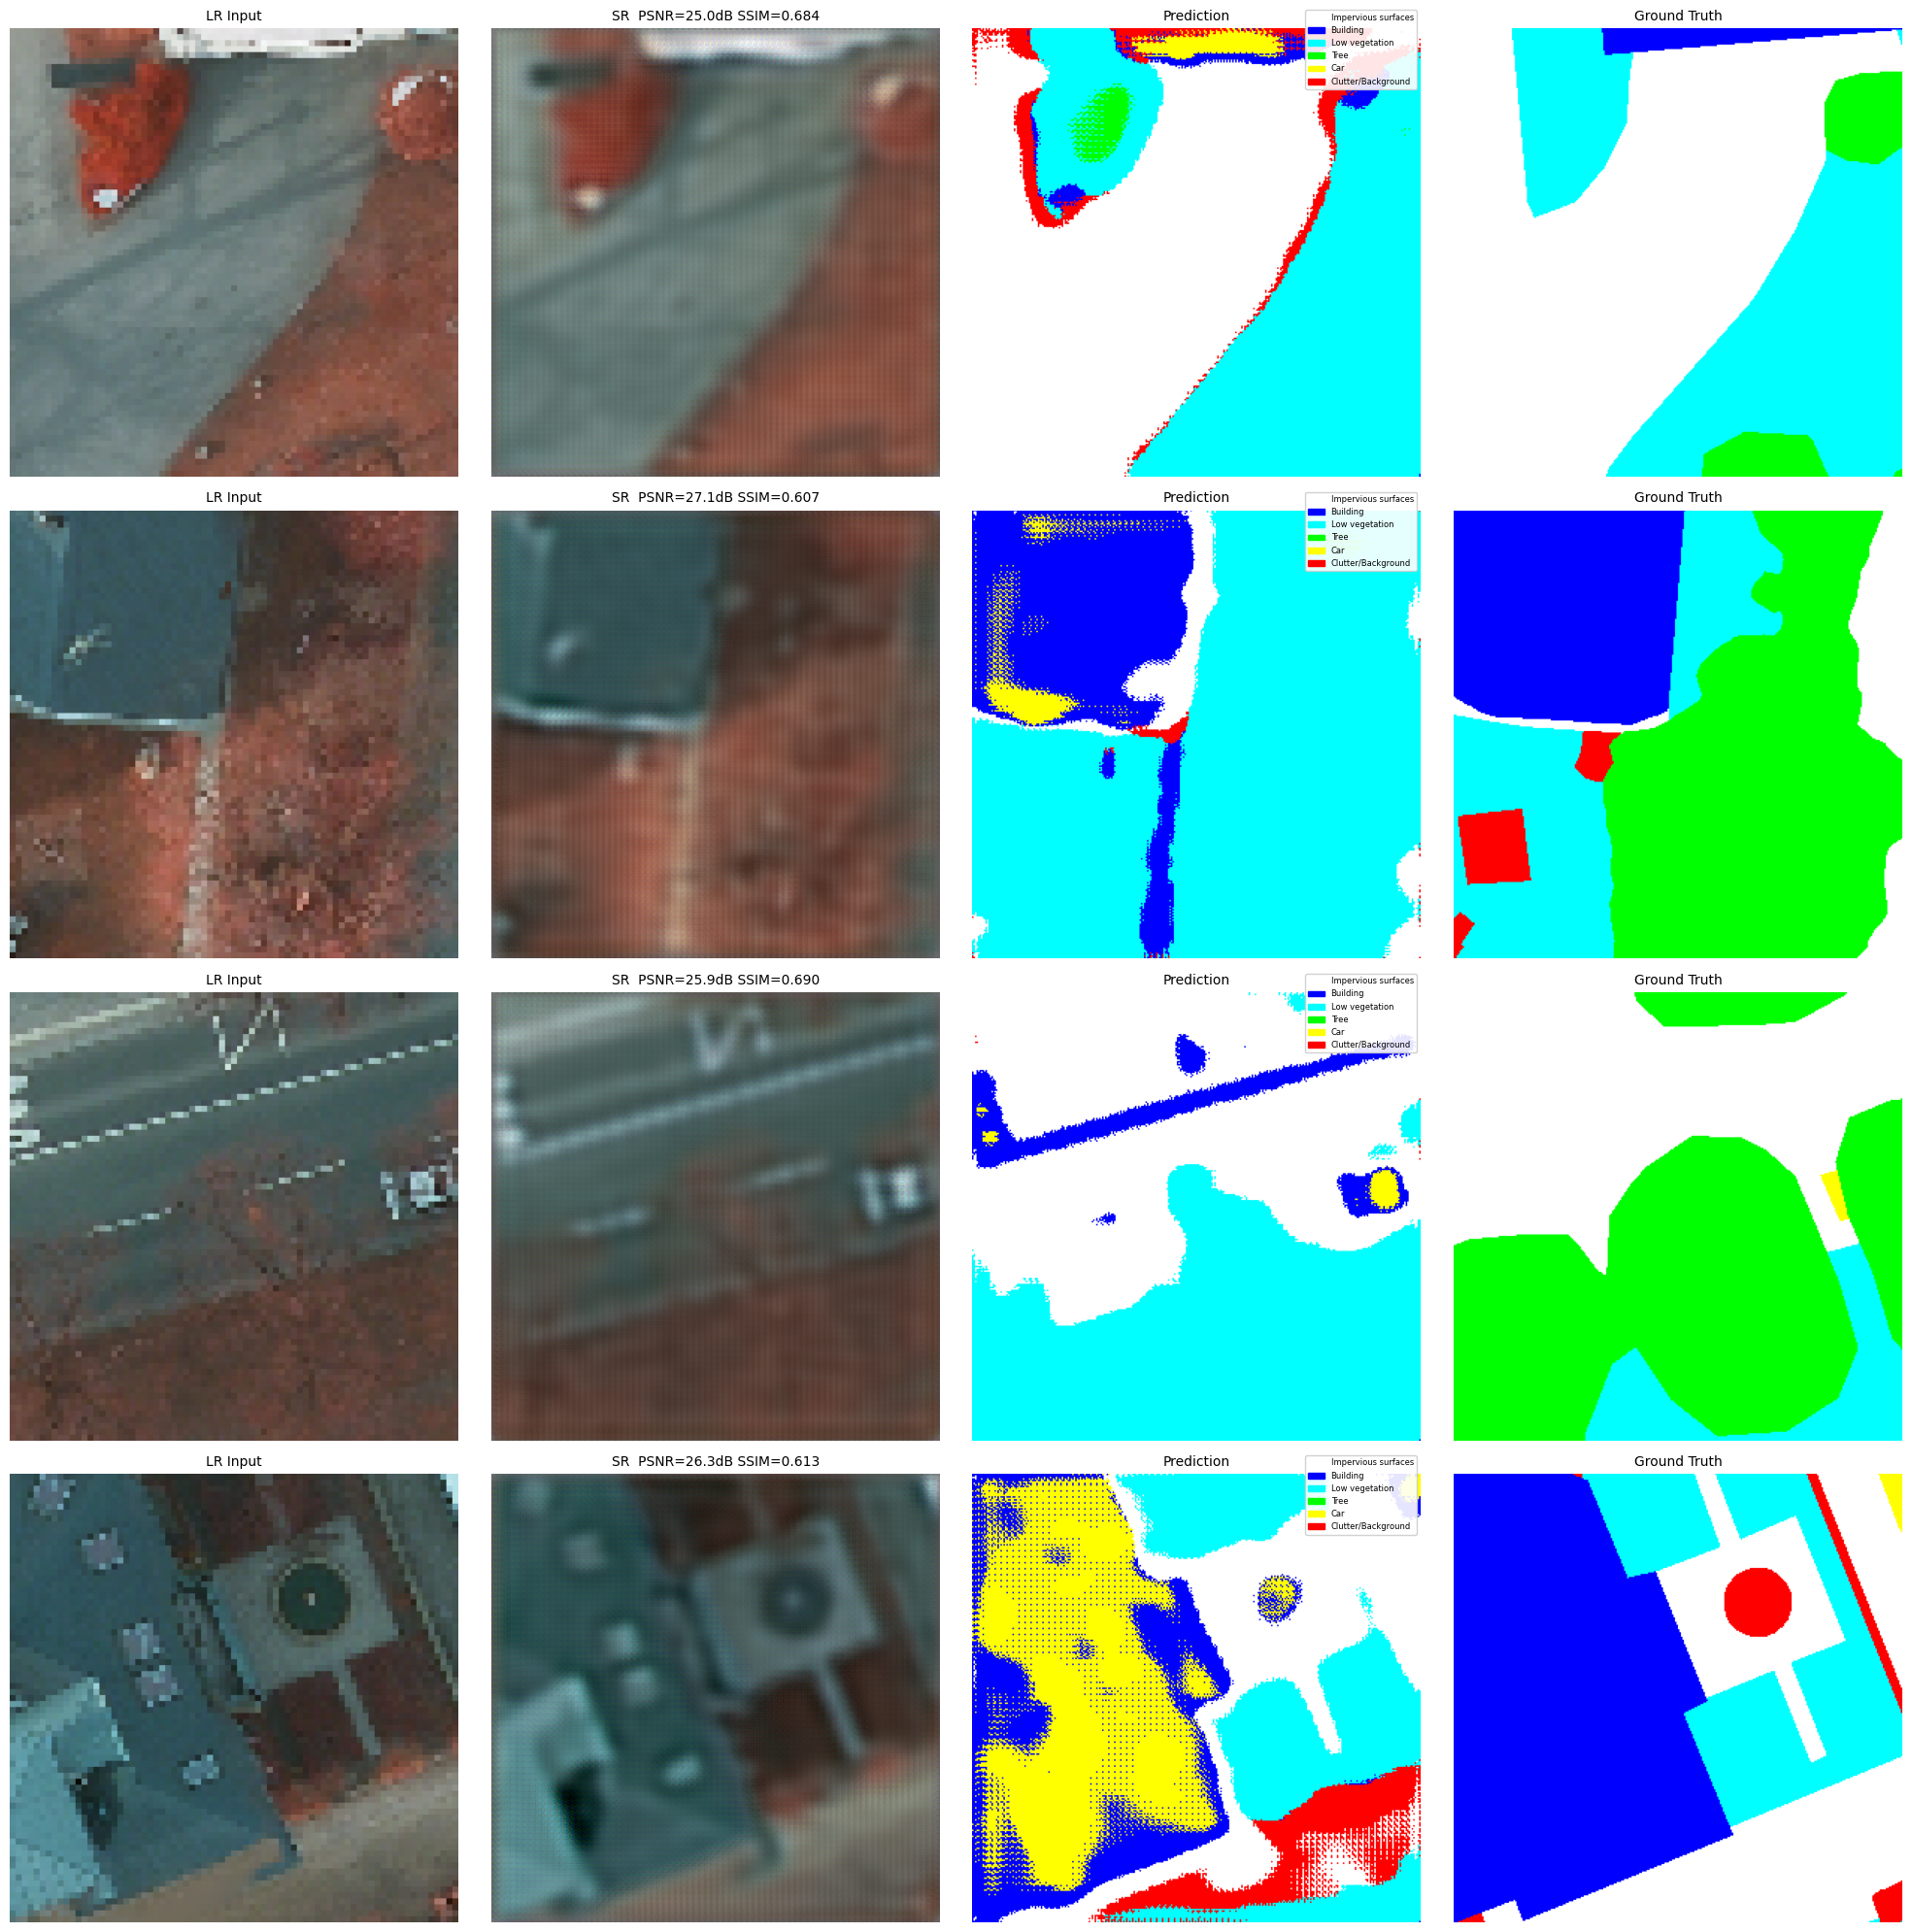

>>> Saved: sample_output.png


In [10]:
model = evaluate(model, save_path=BEST_MODEL_PATH)
visualize_sample(model)
